Modules

In [1]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

<h1>Affichage du jeu de données</h1>

<h2> Analyse </h2>

In [ ]:
path = "../RH_dataset.csv"

df = pd.read_csv(path, sep=";")

df.describe()

FileNotFoundError: [Errno 2] No such file or directory: '../REXIA_course/RH_dataset.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  object 
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  object 
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  l

Affichage des valeurs nulles

In [ ]:
df.isnull().sum()

Famille d'emploi                0
Dernière promotion (mois)       0
Dernière augmentation (mois)    0
Début de contrat (années)       0
Ancienneté groupe (années)      0
Etablissement                   0
Âge (années)                    0
Parent                          0
Niveau hiérarchique             0
Salaire (Euros)                 0
Statut marital                  0
Véhicule                        0
matricule                       0
label                           0
dtype: int64

Affichage de la matrice de corrélation

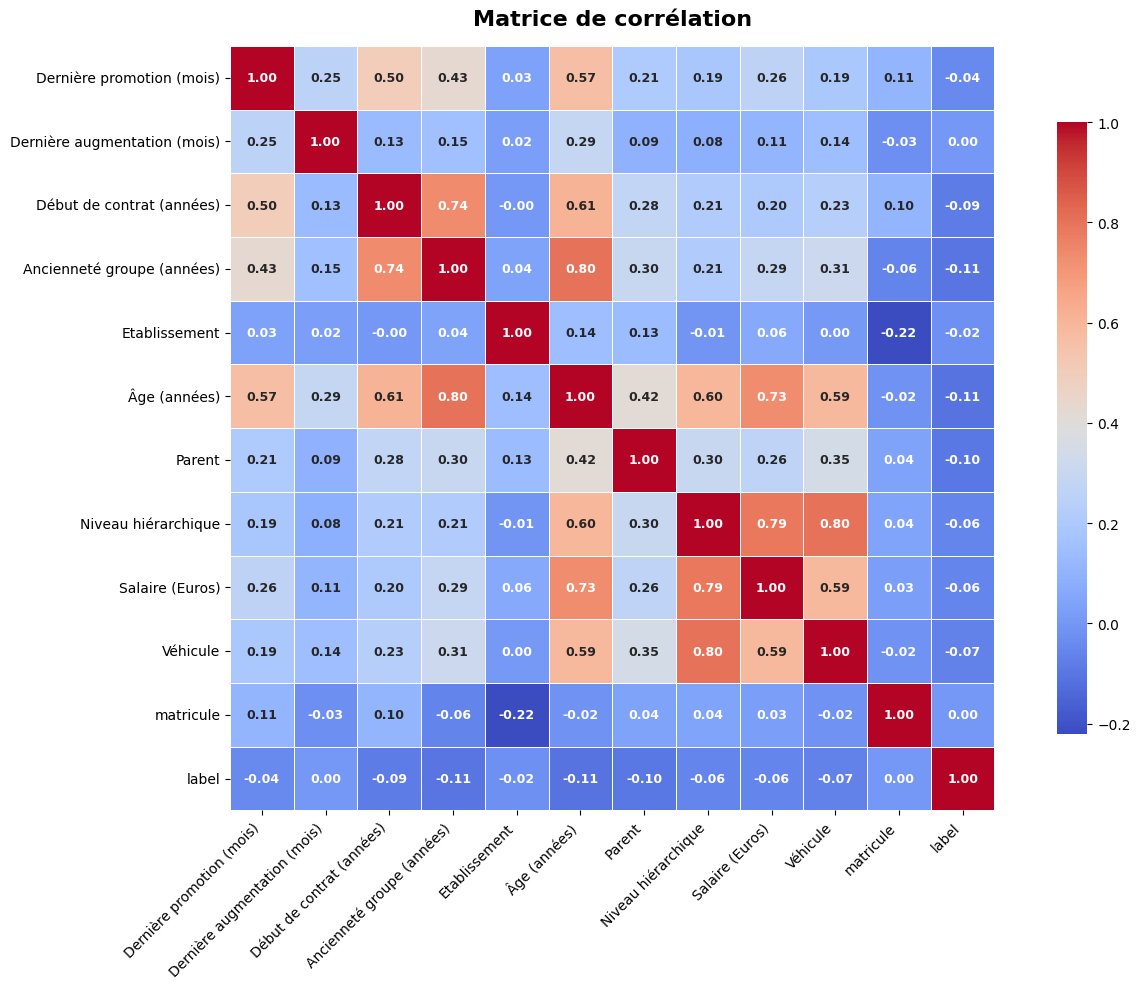

In [ ]:
# Affichage de la matrice de corrélation en grandissant les valeurs numériques
num_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sb.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    annot_kws={"size": 9, "fontweight": "bold"},
    cbar_kws={"shrink": 0.8},
)
plt.title("Matrice de corrélation", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

On peut donc constater que les variables "âge" et "ancienneté" sont fortement corrélées, ce qui est logique. 
De même, les variables "salaire" et "âge"/"niveau hiérarchique" sont également corrélées, ce qui peut s'expliquer par le fait que les employés plus anciens ont généralement des salaires plus élevés.

Détection des outliers

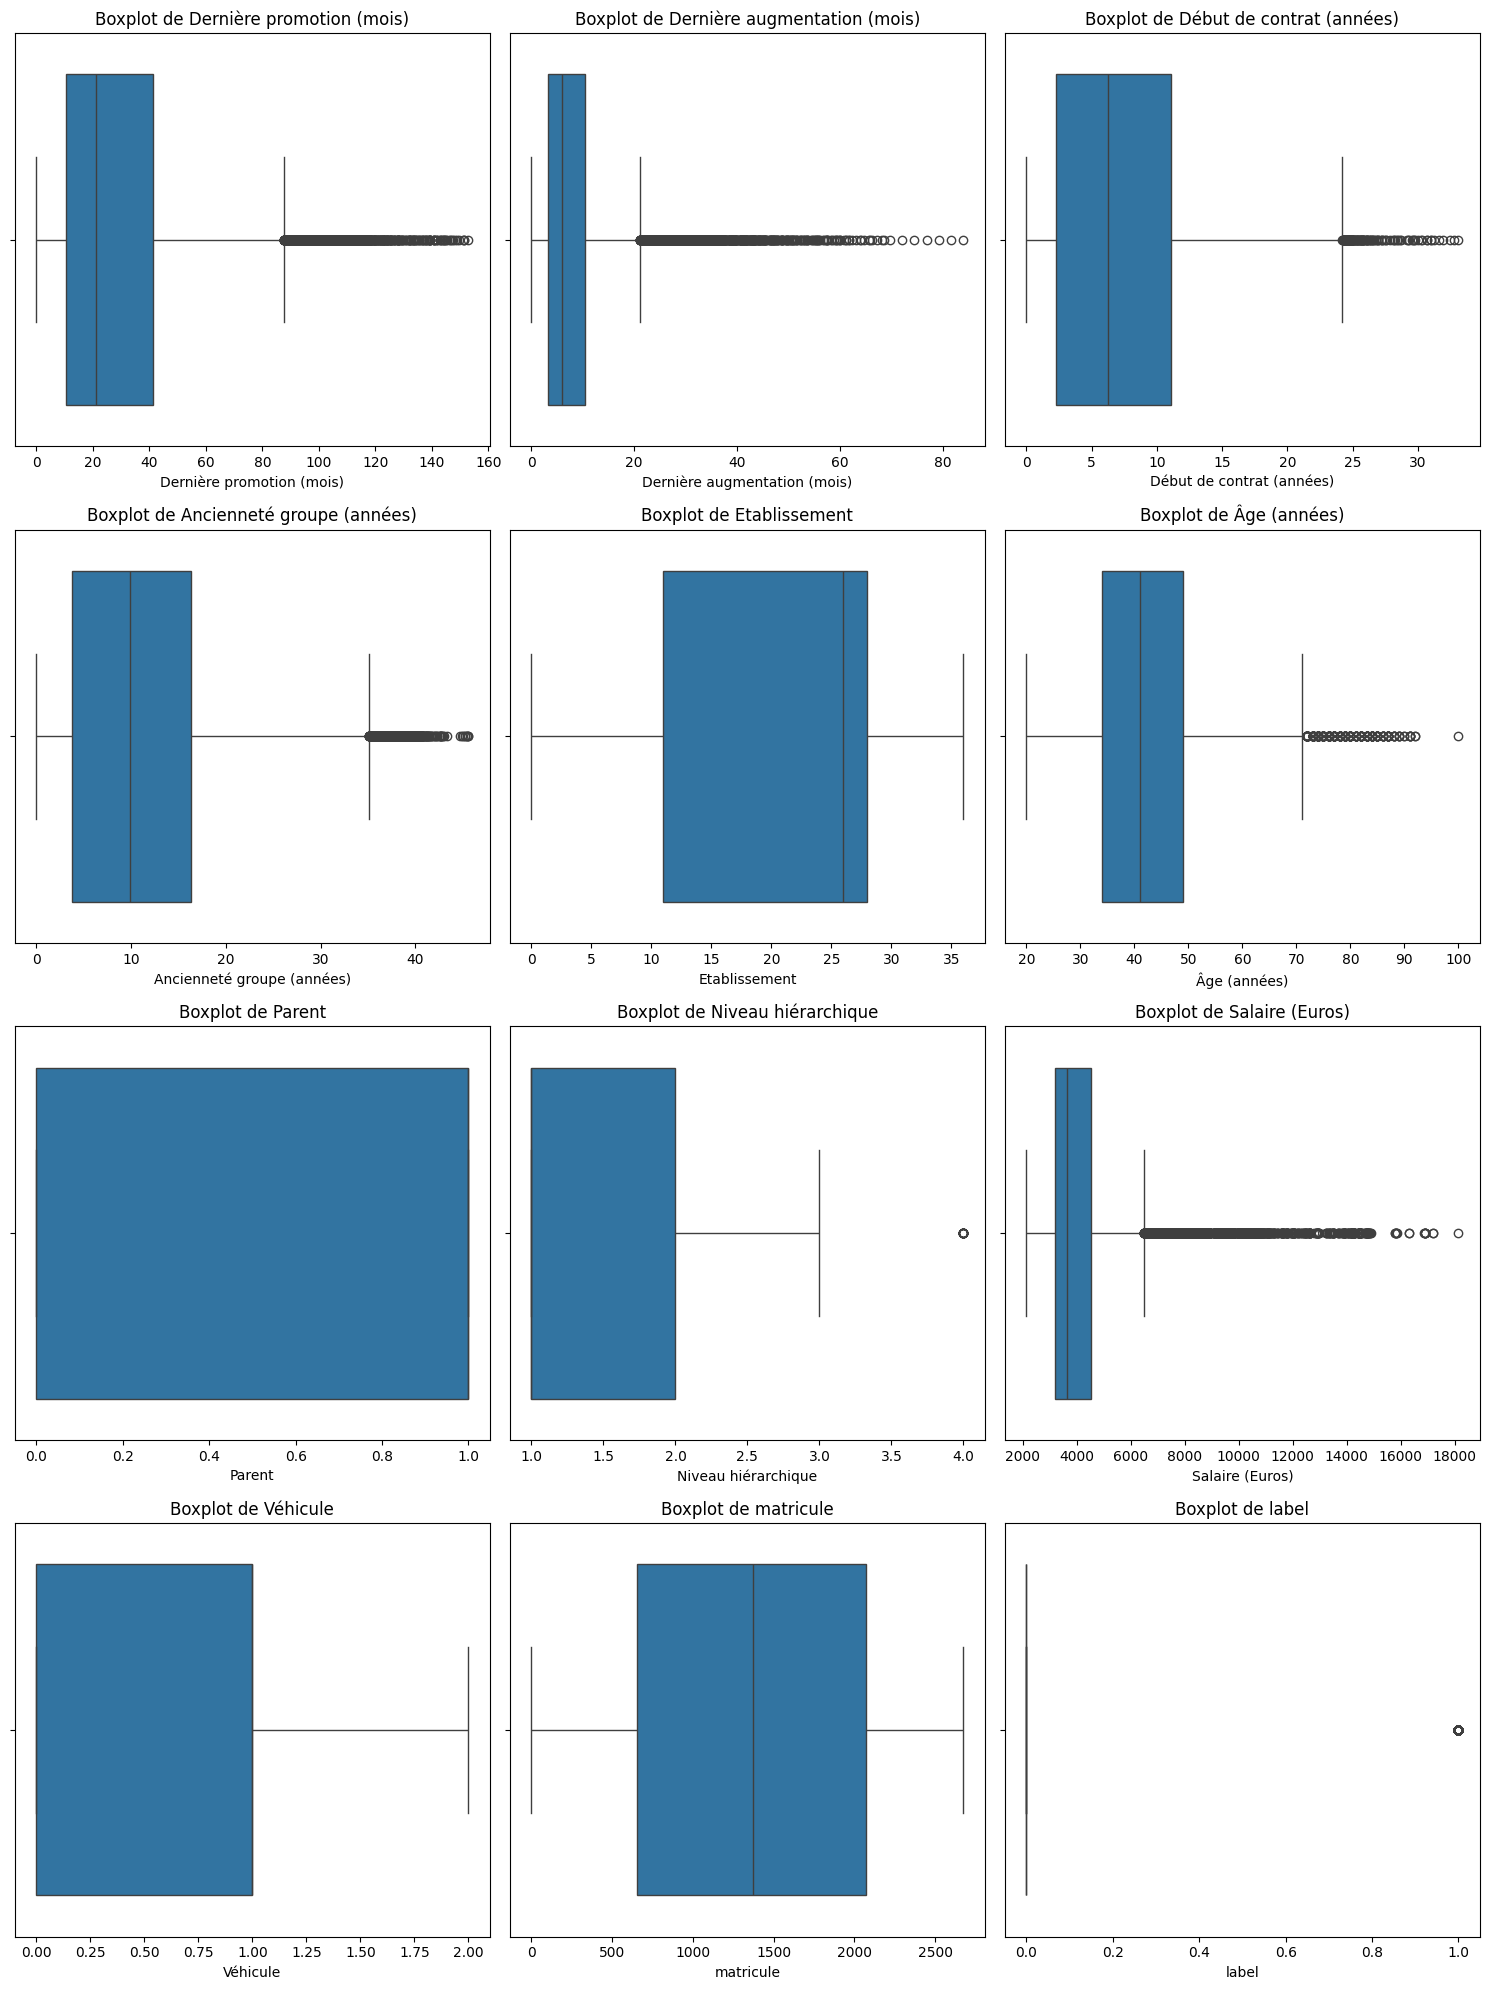

In [ ]:
def outliers_displaying(df):

    num_cols = df.select_dtypes(include=np.number).columns
    num_plots = len(num_cols)
    cols = 3  # Nombre de colonnes dans la grille
    rows = (num_plots + cols - 1) // cols  # Calcul du nombre de lignes nécessaires     
    plt.figure(figsize=(15, 5 * rows))  # Ajustement de la taille de la figure
    for i, col in enumerate(num_cols):
        plt.subplot(rows, cols, i + 1)  # Positionnement du subplot
        sb.boxplot(x=df[col])
        plt.title(f"Boxplot de {col}")
    plt.tight_layout()  # Ajustement de l'espacement entre les subplots
    plt.show()

outliers_displaying(df)

Affichage des distributions des variables numériques

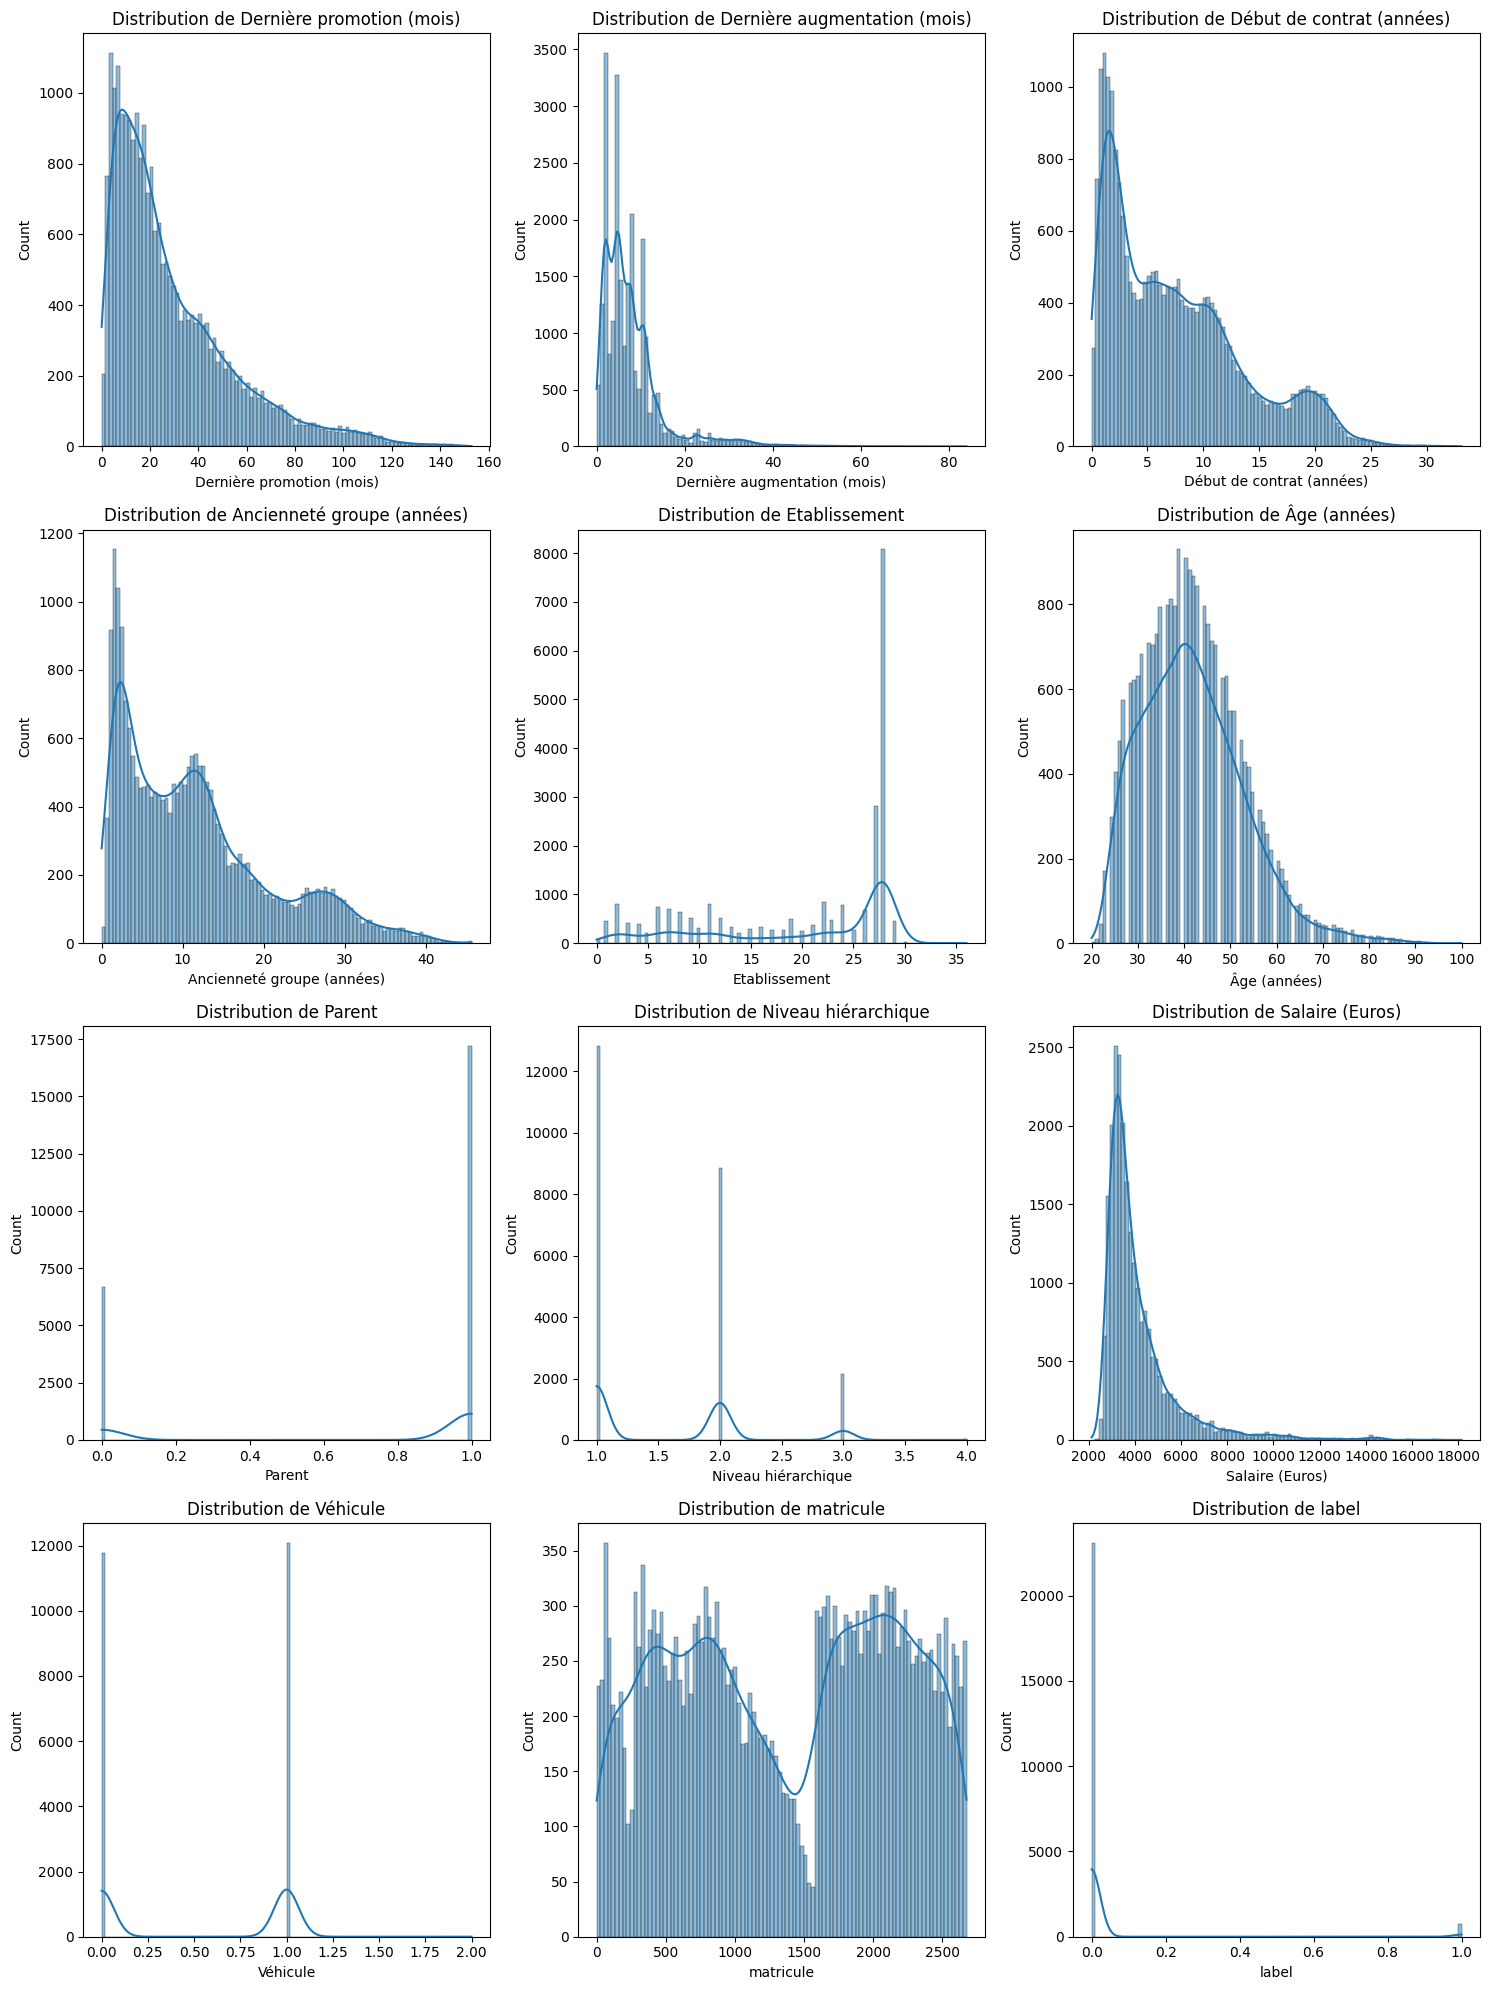

In [ ]:
def distribution_displaying(df):
    num_cols = df.select_dtypes(include=np.number).columns
    num_plots = len(num_cols)
    cols = 3  # Nombre de colonnes dans la grille
    rows = (num_plots + cols - 1) // cols  # Calcul du nombre de lignes nécessaires     
    plt.figure(figsize=(15, 5 * rows))  # Ajustement de la taille de la figure
    for i, col in enumerate(num_cols):
        plt.subplot(rows, cols, i + 1)  # Positionnement du subplot
        sb.histplot(df[col], kde=True, bins=100)
        plt.title(f"Distribution de {col}")
    plt.tight_layout()  # Ajustement de l'espacement entre les subplots
    plt.show()

distribution_displaying(df)

<h2> Exhibition du parcours d'un employé qui a démissionné et celui d'un employé qui n'a pas démissionné </h2>

In [ ]:
df_demission = df[df["label"] == 1]
df_non_demission = df[df["label"] == 0]

df_demission.info()

df_demission.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 755 entries, 3 to 23843
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              755 non-null    object 
 1   Dernière promotion (mois)     755 non-null    float64
 2   Dernière augmentation (mois)  755 non-null    float64
 3   Début de contrat (années)     755 non-null    float64
 4   Ancienneté groupe (années)    755 non-null    float64
 5   Etablissement                 755 non-null    int64  
 6   Âge (années)                  755 non-null    int64  
 7   Parent                        755 non-null    int64  
 8   Niveau hiérarchique           755 non-null    int64  
 9   Salaire (Euros)               755 non-null    int64  
 10  Statut marital                755 non-null    object 
 11  Véhicule                      755 non-null    int64  
 12  matricule                     755 non-null    int64  
 13  label   

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.000000,755.0
mean,23.845894,8.060728,4.673563,6.245868,18.950993,35.270199,0.484768,1.344371,3635.705960,0.324503,1365.797351,1.0
std,17.400095,6.594335,4.034534,5.097133,9.963939,7.657011,0.500099,0.535805,1035.558766,0.468499,831.314521,0.0
min,0.280000,0.000000,0.100000,0.000000,0.000000,22.000000,0.000000,1.000000,2561.000000,0.000000,1.000000,1.0
25%,11.460000,3.895000,1.770000,2.360000,8.000000,29.000000,0.000000,1.000000,3001.000000,0.000000,634.500000,1.0
50%,19.350000,6.890000,3.200000,4.480000,25.000000,34.000000,0.000000,1.000000,3338.000000,0.000000,1232.000000,1.0
75%,31.179999,10.510000,6.315000,9.075000,28.000000,40.000000,1.000000,2.000000,3915.000000,1.000000,2199.000000,1.0
max,99.680000,41.709999,21.590000,28.070000,29.000000,65.000000,1.000000,3.000000,10927.000000,1.000000,2666.000000,1.0


In [ ]:
df_non_demission.info()

df_non_demission.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 23102 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23102 non-null  object 
 1   Dernière promotion (mois)     23102 non-null  float64
 2   Dernière augmentation (mois)  23102 non-null  float64
 3   Début de contrat (années)     23102 non-null  float64
 4   Ancienneté groupe (années)    23102 non-null  float64
 5   Etablissement                 23102 non-null  int64  
 6   Âge (années)                  23102 non-null  int64  
 7   Parent                        23102 non-null  int64  
 8   Niveau hiérarchique           23102 non-null  int64  
 9   Salaire (Euros)               23102 non-null  int64  
 10  Statut marital                23102 non-null  object 
 11  Véhicule                      23102 non-null  int64  
 12  matricule                     23102 non-null  int64  
 13  label 

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.000000,23102.0
mean,29.644239,7.930876,7.623685,11.808123,20.234568,41.979482,0.728422,1.561423,4185.813220,0.512813,1361.107437,0.0
std,25.699102,7.579271,6.015819,9.270018,9.270229,11.042857,0.444783,0.660378,1671.420167,0.500193,792.958687,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,0.000000,0.000000,0.0
25%,10.550000,3.142500,2.330000,3.920000,11.000000,34.000000,0.000000,1.000000,3203.000000,0.000000,658.000000,0.0
50%,21.299999,5.850000,6.430000,10.080000,26.000000,41.000000,1.000000,1.000000,3640.500000,1.000000,1379.500000,0.0
75%,41.689999,10.330000,11.190000,16.607501,28.000000,49.000000,1.000000,2.000000,4536.750000,1.000000,2068.000000,0.0
max,152.970001,84.050003,33.119999,45.619999,36.000000,100.000000,1.000000,4.000000,18137.000000,2.000000,2675.000000,0.0


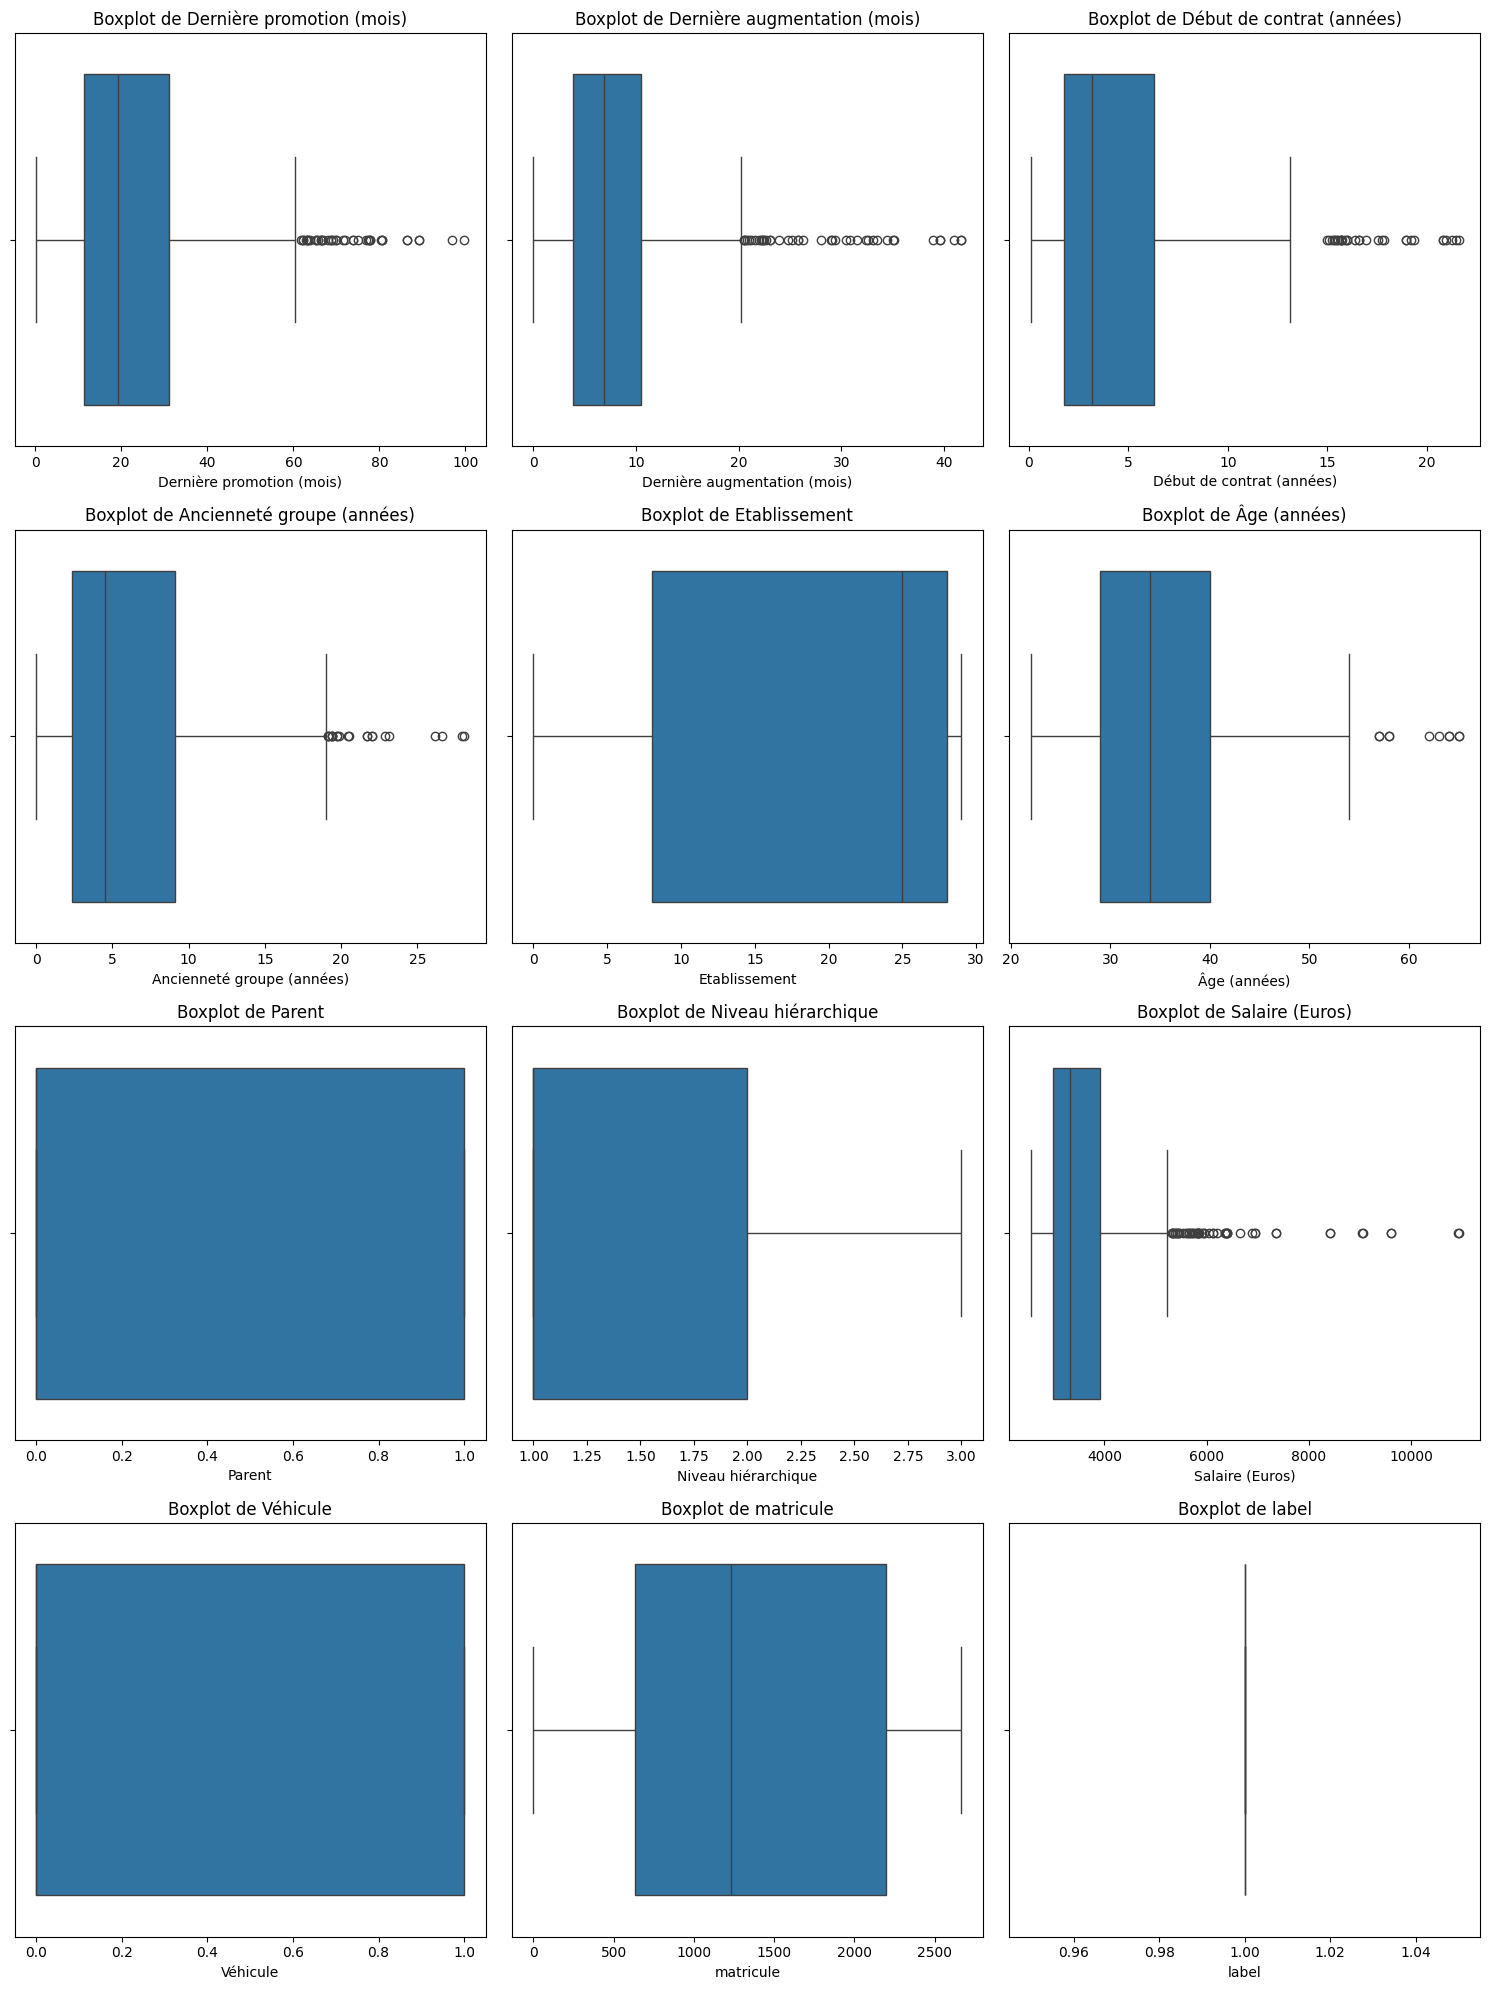

In [ ]:
outliers_displaying(df_demission)

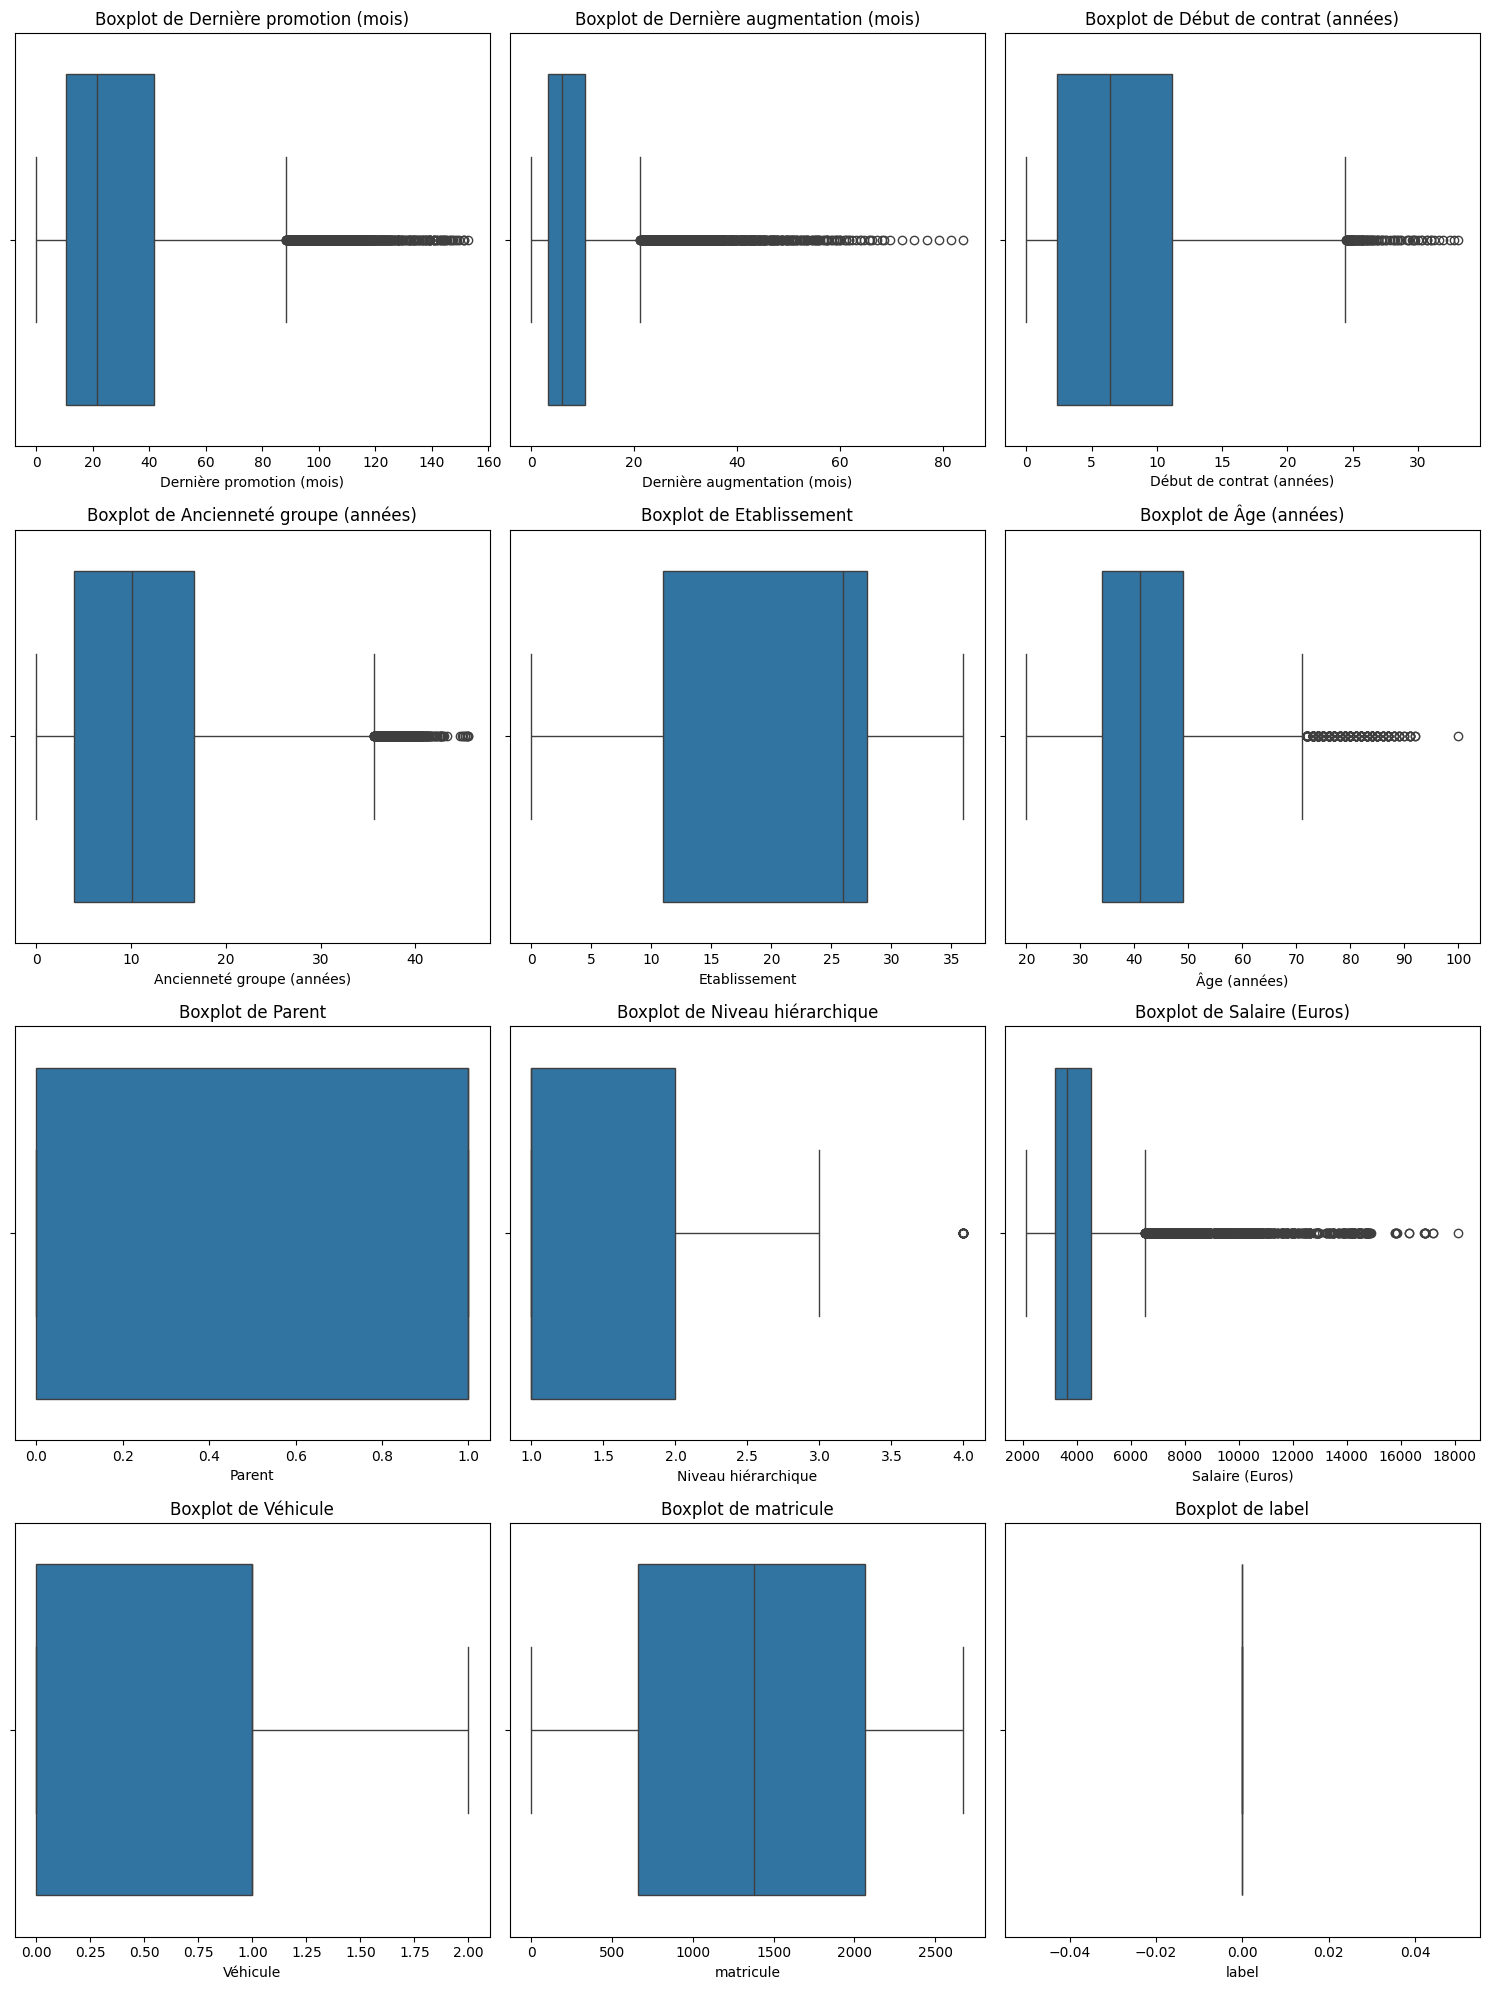

In [ ]:
outliers_displaying(df_non_demission)

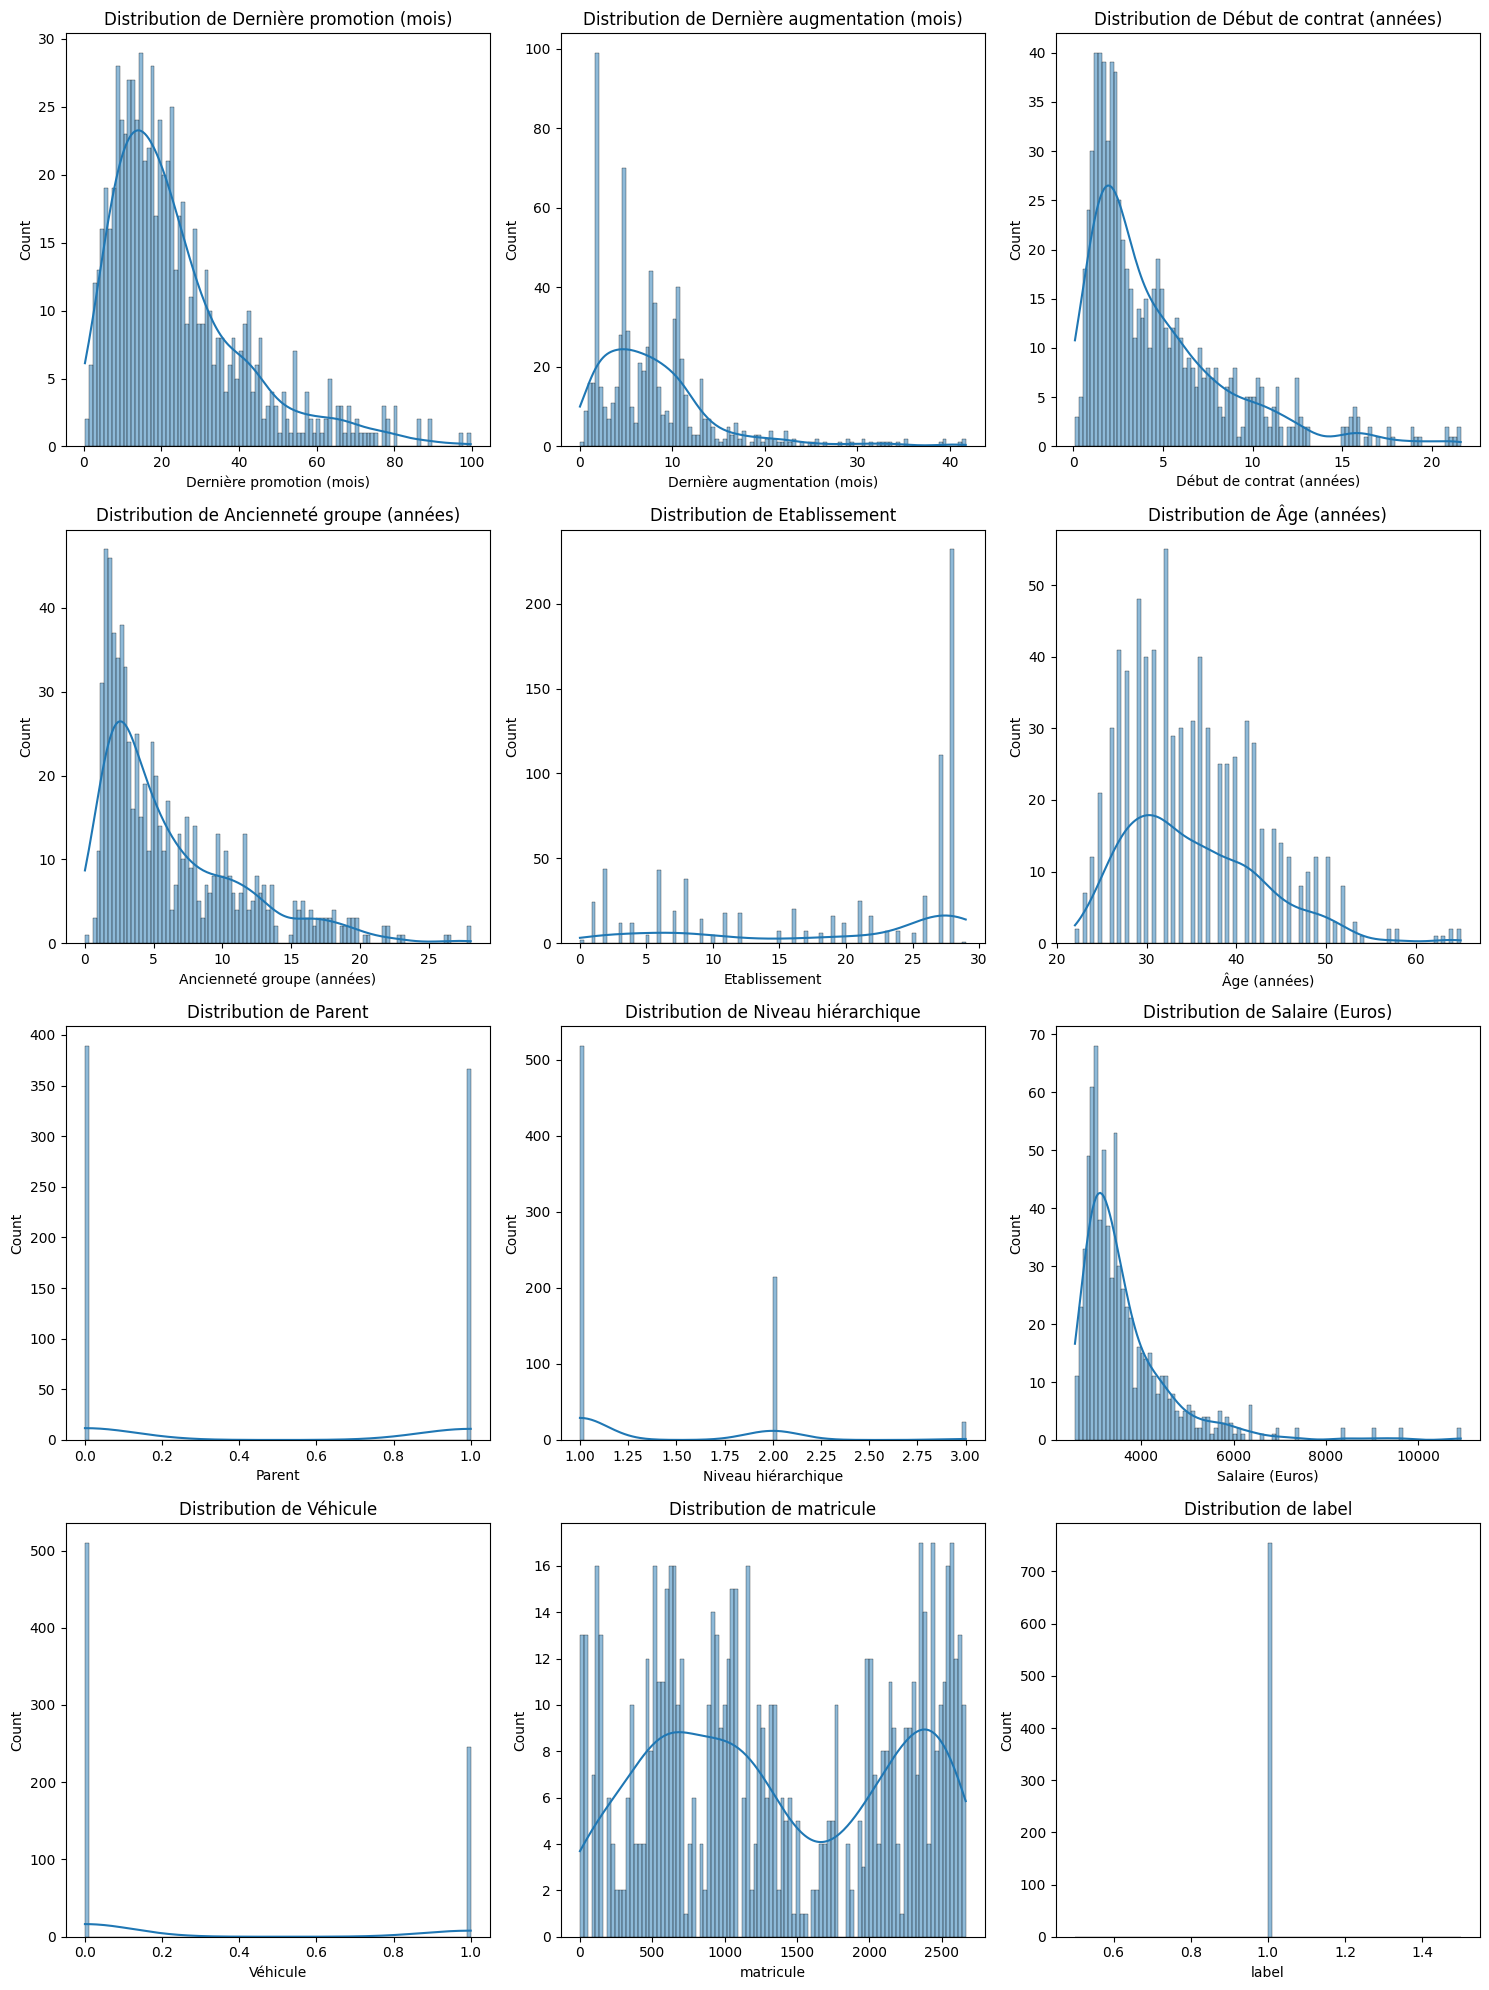

In [ ]:
distribution_displaying(df_demission)

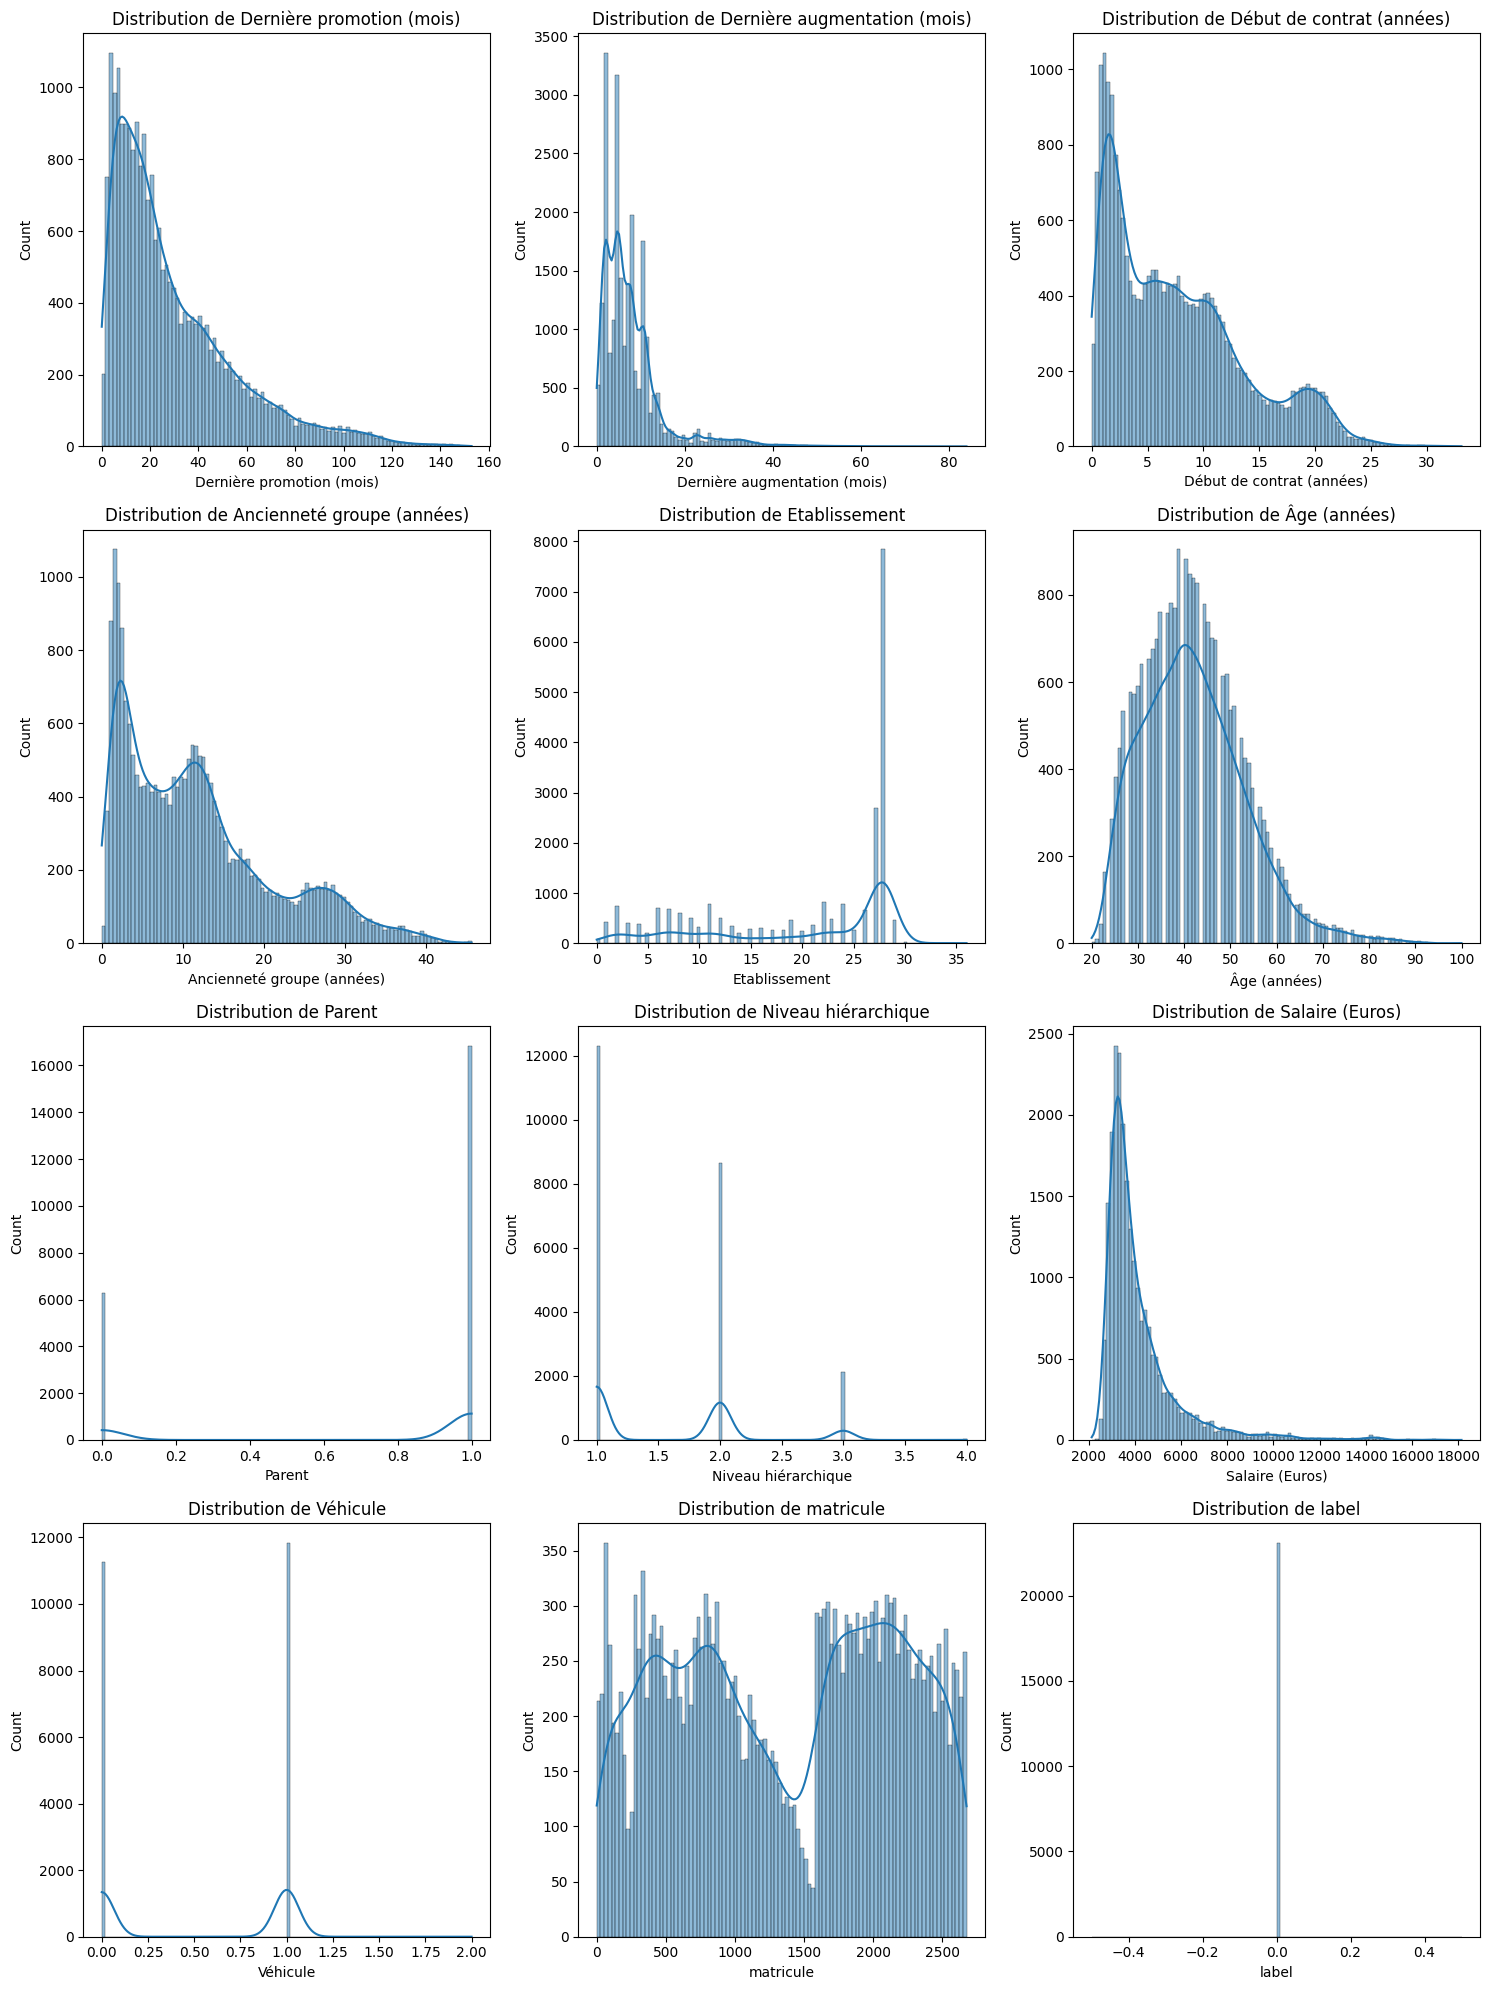

In [ ]:
distribution_displaying(df_non_demission)

Exhibition d'un seul parcours

In [ ]:
random_employee_demission = df_demission.sample(n=1, random_state=42)
print(random_employee_demission)

Parcours de l'employé qui a démissionné :
        Famille d'emploi  Dernière promotion (mois)  \
9416  Etudes & Technique                  25.559999   

      Dernière augmentation (mois)  Début de contrat (années)  \
9416                          4.54                       3.22   

      Ancienneté groupe (années)  Etablissement  Âge (années)  Parent  \
9416                        3.31             26            29       0   

      Niveau hiérarchique  Salaire (Euros) Statut marital  Véhicule  \
9416                    1             2752    Union libre         0   

      matricule  label  
9416         17      1  


In [ ]:
cols_to_plot = ['Salaire (Euros)', 'Âge (années)', 'Ancienneté groupe (années)']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f"{col} vs Démission")
plt.tight_layout()
plt.show()